In [94]:
import numpy as np
import matplotlib.pyplot as plt
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import TikhonovRegularizationSetting, RegularizationSetting, RegSolver
from regpy.solvers.linear.semismoothNewton import SemismoothNewton_bilateral, SemismoothNewton_nonneg, SemismoothNewtonAlphaGrid
from regpy.solvers.linear.tikhonov import TikhonovCG
from regpy.solvers.nonlinear.fista import FISTA
import regpy.functionals as fct
from regpy.hilbert import L2
from regpy.stoprules import CountIterations

2024-06-16 17:48:51,888 INFO TikhonovCG           :: it.8 kappa=1.7037779512754625 err/Tol rel X:6.6e-01/9.9e-01 
2024-06-16 17:48:51,890 INFO TikhonovCG           :: Solver converged after 8 iteration.


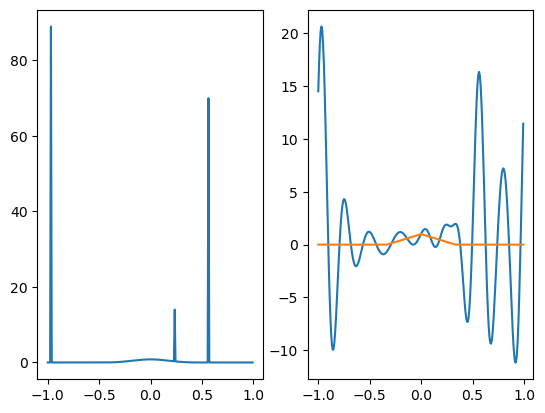

In [95]:
n = 256
sigma = 0.1
alpha = 1e-3/sigma
grid = UniformGridFcts((-1,1,n),periodic=True)
conv = GaussianBlur(grid,kernel_width=0.1)

x = grid.coords[0]
fdag = np.maximum(0,1-3*np.abs(x))
gobs = conv(fdag)

for j in range(3):
    k = np.random.randint(n)
    gobs[k] = np.random.randint(100)

setting = RegularizationSetting(conv,L2,L2)
solver = TikhonovCG(setting=setting, data = gobs, regpar = 1e-2)
fal,_ = solver.run()

fig, (ax1,ax2) =plt.subplots(1,2)
ax1.plot(x,gobs)
ax2.plot(x,fal)
ax2.plot(x,fdag)

In [96]:
Sdat = fct.Huber(grid,sigma=sigma)
huber_setting = TikhonovRegularizationSetting(conv,L2,Sdat,alpha,data_fid_shift=gobs)
dual_setting = huber_setting.DualSetting()
solver = FISTA(dual_setting)
p,Tstar_p = solver.run(stoprule=CountIterations(200))

2024-06-16 17:48:52,561 INFO CountIterations      :: iteration = 1 / 200
2024-06-16 17:48:52,564 INFO CountIterations      :: iteration = 2 / 200
2024-06-16 17:48:52,571 INFO CountIterations      :: iteration = 3 / 200
2024-06-16 17:48:52,576 INFO CountIterations      :: iteration = 4 / 200
2024-06-16 17:48:52,580 INFO CountIterations      :: iteration = 5 / 200
2024-06-16 17:48:52,587 INFO CountIterations      :: iteration = 6 / 200
2024-06-16 17:48:52,592 INFO CountIterations      :: iteration = 7 / 200
2024-06-16 17:48:52,596 INFO CountIterations      :: iteration = 8 / 200
2024-06-16 17:48:52,602 INFO CountIterations      :: iteration = 9 / 200
2024-06-16 17:48:52,605 INFO CountIterations      :: iteration = 10 / 200
2024-06-16 17:48:52,609 INFO CountIterations      :: iteration = 11 / 200
2024-06-16 17:48:52,613 INFO CountIterations      :: iteration = 12 / 200
2024-06-16 17:48:52,619 INFO CountIterations      :: iteration = 13 / 200
2024-06-16 17:48:52,624 INFO CountIterations   

In [97]:
huber_setting.data_fid.shift

array([1.11022302e-16, 5.55111512e-17, 1.11022302e-16, 1.11022302e-16,
       8.90000000e+01, 5.55111512e-17, 1.66533454e-16, 1.66533454e-16,
       1.66533454e-16, 1.11022302e-16, 5.55111512e-17, 1.11022302e-16,
       2.22044605e-16, 1.66533454e-16, 1.66533454e-16, 2.22044605e-16,
       3.33066907e-16, 7.21644966e-16, 1.60982339e-15, 3.38618023e-15,
       7.60502772e-15, 1.71529457e-14, 3.85802501e-14, 8.54316617e-14,
       1.87239113e-13, 4.05592226e-13, 8.68582983e-13, 1.83852933e-12,
       3.84631216e-12, 7.95283284e-12, 1.62530267e-11, 3.28300720e-11,
       6.55464294e-11, 1.29351377e-10, 2.52316168e-10, 4.86495455e-10,
       9.27215624e-10, 1.74686672e-09, 3.25330685e-09, 5.98943839e-09,
       1.09006670e-08, 1.96126586e-08, 3.48856910e-08, 6.13475488e-08,
       1.06659182e-07, 1.83342502e-07, 3.11605615e-07, 5.23647019e-07,
       8.70117618e-07, 1.42967965e-06, 2.32293598e-06, 3.73242080e-06,
       5.93084877e-06, 9.32040913e-06, 1.44865505e-05, 2.22703972e-05,
      

In [98]:
solver = SemismoothNewton_bilateral(dual_setting)
p2,Tstar_p2 = solver.run(stoprule=CountIterations(200))

2024-06-16 17:48:54,147 INFO TikhonovCG           :: it.1 kappa=1.0 err/Tol abs X: 5.2e-22/1.0e-05
2024-06-16 17:48:54,149 INFO TikhonovCG           :: Solver converged after 1 iteration.
2024-06-16 17:48:54,151 INFO CountIterations      :: iteration = 1 / 200
2024-06-16 17:48:54,159 INFO TikhonovCG           :: it.1 kappa=1.0 err/Tol abs X: 4.3e-22/1.0e-05
2024-06-16 17:48:54,160 INFO TikhonovCG           :: Solver converged after 1 iteration.
2024-06-16 17:48:54,164 INFO CountIterations      :: iteration = 2 / 200
2024-06-16 17:48:54,165 INFO SemismoothNewton_bilateral :: Solver converged after 1 iteration.


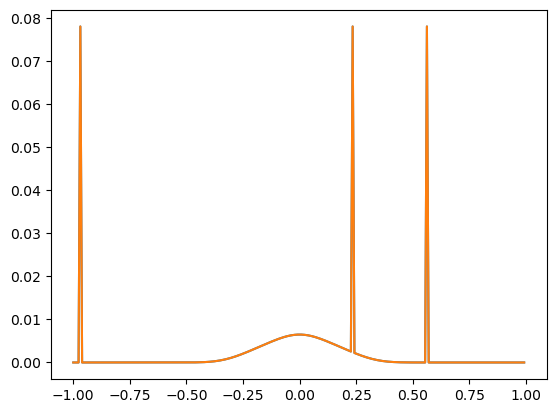

In [99]:
f2 = huber_setting.TstarDualToPrimalSolution(Tstar_p)
f2SS = huber_setting.TstarDualToPrimalSolution(Tstar_p2)
plt.plot(x,p2)
plt.plot(x,p)

1.4828467093315671e-08

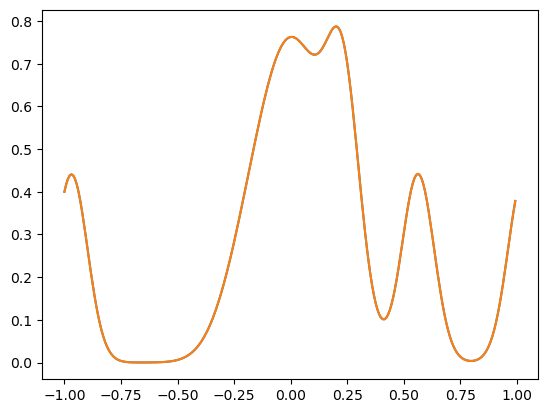

In [100]:
plt.plot(x,f2)
plt.plot(x,f2SS)
np.linalg.norm(f2-f2SS)/np.linalg.norm(f2)